# 1. Librerias y cargade base de datos

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [3]:
house_price = pd.read_csv("data.csv")

In [4]:
house_price.head(20)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [5]:
house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
house_price.describe(include='all')  # Para ver también las categóricas

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
count,4600,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600,4600,4600,4600
unique,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4525,44,77,1
top,2014-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1573,148,4600
mean,NaN,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,NaN,NaN,NaN,NaN
std,NaN,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,NaN,NaN,NaN,NaN
min,NaN,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,NaN,NaN,NaN,NaN


# Asimetría y outliers

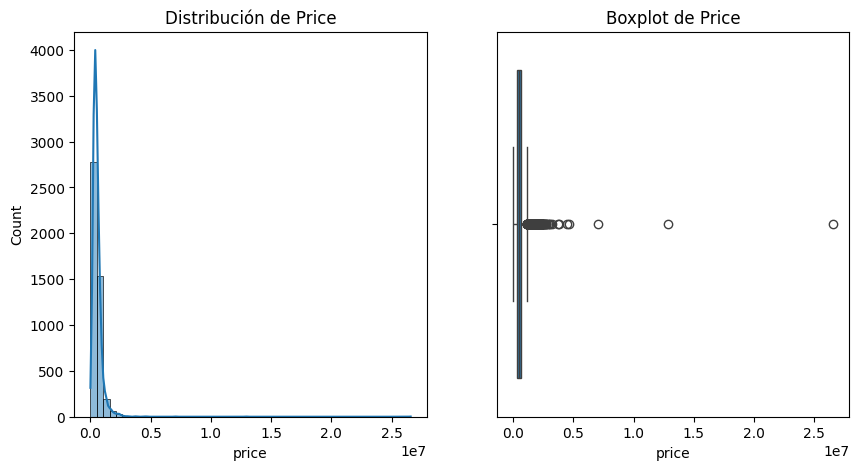

In [9]:
# Distribución de price
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(house_price['price'], bins=50, kde=True)
plt.title('Distribución de Price')

plt.subplot(1,2,2)
sns.boxplot(x=house_price['price'])
plt.title('Boxplot de Price')
plt.show()

Histograma: Se ve una distribución altamente sesgada a la derecha (long tail). La mayoría de las casas están en el rango bajo (0-1M), pero hay valores extremos que llegan hasta 26M. Esto confirma que necesitamos transformar la variable objetivo.

Boxplot: Muestra múltiples outliers por encima del bigote superior. Esto es esperable en precios de vivienda, pero debemos decidir si los eliminamos o los mantenemos. En modelos de regresión, a veces es mejor mantenerlos si son reales, pero aplicar una transformación logarítmica para reducir su impacto.

Decisión: Aplicaremos log1p a price para normalizar la distribución. Esto creará una nueva variable log_price que usaremos para el modelo.

# Relación precio VS sqft_living


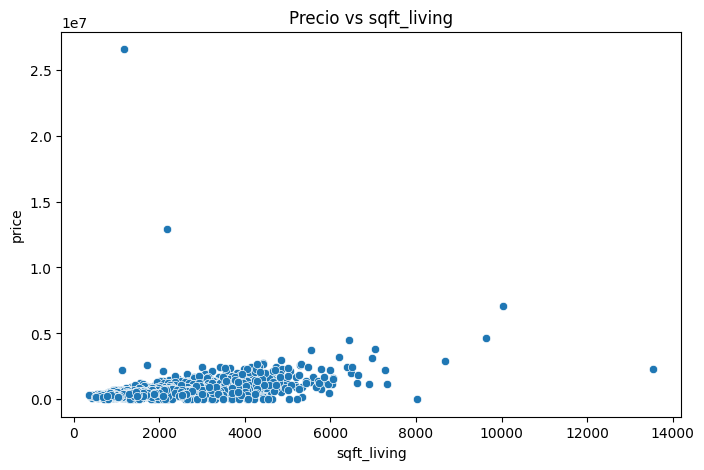

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=house_price)
plt.title('Precio vs sqft_living')
plt.show()

Gráfico de dispersión: Se observa una relación positiva (a mayor sqft_living, mayor precio), pero con mucha heterogeneidad. Hay casas con poco sqft y precios altos (probablemente por ubicación) y casas grandes con precios moderados.

Outliers visibles: El punto en la parte superior (cerca de 26M) es un outlier extremo. También hay algunos puntos con sqft_living > 10,000 que merecen revisión.

Patrón no lineal: La relación parece tener una pendiente que cambia. Esto sugiere que podríamos necesitar términos polinómicos o transformaciones de las predictoras también.

In [13]:
# Verificar precios cero
cero_price = house_price[house_price['price'] == 0].shape[0]
print(f"Filas con price = 0: {cero_price}")

# Si son pocas, eliminarlas
if cero_price < 50:  # Umbral arbitrario, podemos ajustar
    house_price = house_price[house_price['price'] != 0]
    print(f"Se eliminaron {cero_price} filas con precio cero.")
else:
    print("Hay muchos precios cero, habría que investigar más.")

Filas con price = 0: 49
Se eliminaron 49 filas con precio cero.


49 filas eliminadas: Representan solo el 1.06% del dataset (49/4600 ≈ 1.06%). Es una pérdida aceptable. Ahora el dataset tiene 4551 filas.

Columnas numéricas: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


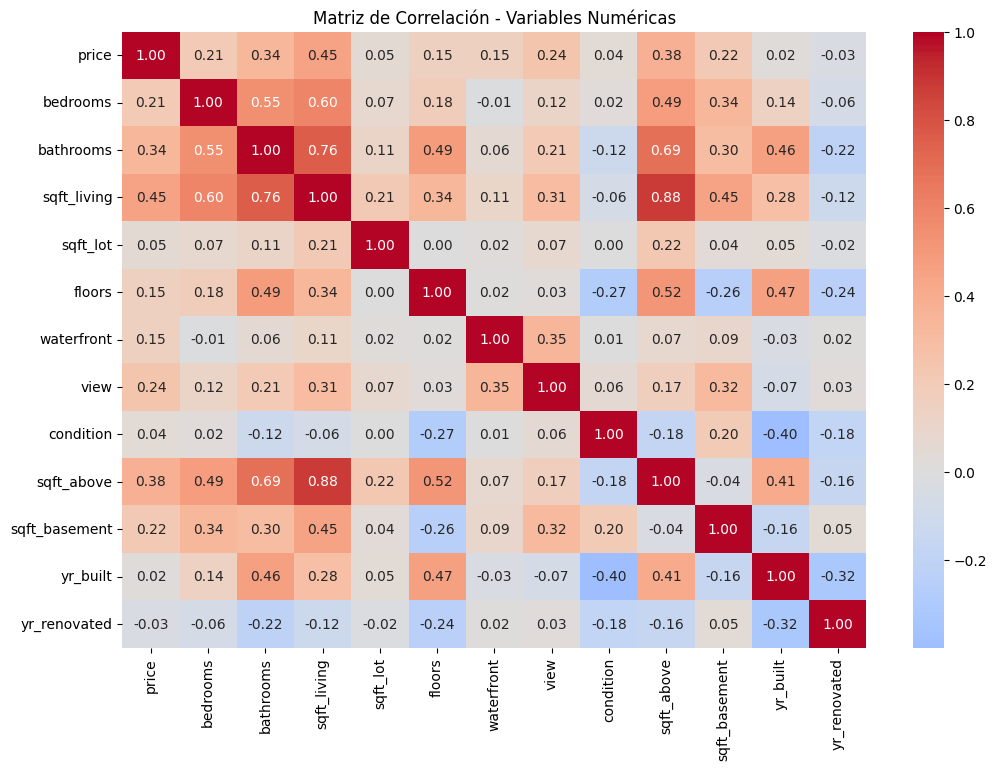

In [16]:
# Seleccionar solo columnas numéricas (int64, float64)
numeric_cols = house_price.select_dtypes(include=[np.number]).columns.tolist()
print("Columnas numéricas:", numeric_cols)

# Calcular matriz de correlación
corr_matrix = house_price[numeric_cols].corr()

# Visualizar
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

Correlaciones fuertes con price:

sqft_living (0.45): La más alta, lógico.

sqft_above (0.38): También importante.

bathrooms (0.34) y bedrooms (0.21): Moderadas.

view (0.24) y waterfront (0.15): Influyen pero no tanto.

Correlaciones entre predictoras (multicolinealidad):

sqft_living con sqft_above (0.88) y con bathrooms (0.76): Muy altas. Esto puede causar problemas en regresión lineal porque las variables aportan información redundante. Podríamos considerar usar solo una de ellas o combinarlas.

bathrooms con sqft_above (0.69) y con bedrooms (0.55).

yr_built con floors (0.47) y con sqft_above (0.41): Casas más nuevas tienden a tener más pisos y más área arriba.

Correlaciones negativas:

yr_built con condition (-0.40): Casas más nuevas tienen peor condición (¿extraño? Tal vez las casas antiguas han sido renovadas o mejor mantenidas). O podría ser que la escala de condition sea al revés.

floors con condition (-0.27).

# Transformación de la variable objetivo

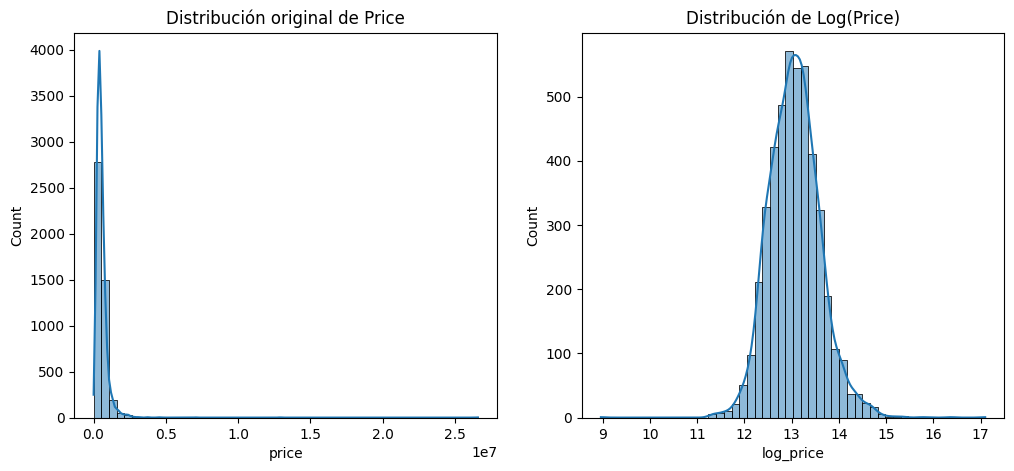

In [17]:
# Crear nueva variable log_price
house_price = house_price[house_price['price'] > 0]  # ya eliminamos los cero
house_price['log_price'] = np.log1p(house_price['price'])  # log1p para evitar problemas con cero (aunque ya no hay)

# Ver distribución
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(house_price['price'], bins=50, kde=True)
plt.title('Distribución original de Price')

plt.subplot(1,2,2)
sns.histplot(house_price['log_price'], bins=50, kde=True)
plt.title('Distribución de Log(Price)')
plt.show()

Análisis de la transformación:
Antes (price original):
Distribución con sesgo extremo a la derecha

Mayoría de valores concentrados cerca de cero

Cola larga hasta 26M

Después (log_price):
Distribución aproximadamente normal (forma de campana)

Rango de 9 a 17 (que corresponde a precio original desde exp(9)≈8,100 hasta exp(17)≈24M)

Media alrededor de 13 (≈ exp(13)≈442,000, cercano a la mediana original)

Ya no se aprecian outliers extremos visualmente

Esto es perfecto para modelos que asumen normalidad (como regresión lineal) y también mejorará el rendimiento de otros algoritmos.

#  Preparación final de datos para modelado

Ahora necesitamos:

Seleccionar características (features)

Crear variables dummy para ciudades y códigos postales

Escalar las variables numéricas

Dividir en entrenamiento y prueba

In [19]:
# 1. Ingeniería de características (como discutimos)
house_price['age'] = 2014 - house_price['yr_built']
house_price['was_renovated'] = (house_price['yr_renovated'] > 0).astype(int)
house_price['years_since_renovation'] = house_price.apply(lambda x: 2014 - x['yr_renovated'] if x['yr_renovated'] > 0 else 0, axis=1)
house_price['has_basement'] = (house_price['sqft_basement'] > 0).astype(int)
house_price['total_sqft'] = house_price['sqft_living'] + house_price['sqft_basement']  # opcional

# 2. Seleccionar features para el modelo
# Definimos variables numéricas y categóricas
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
                    'waterfront', 'view', 'condition', 'sqft_above', 
                    'age', 'years_since_renovation', 'has_basement', 'total_sqft']
# Nota: sqft_basement original ya no la usamos directamente porque creamos has_basement y total_sqft

categorical_features = ['city', 'statezip']
# Excluimos: street (alta cardinalidad), country (constante), date (solo año 2014), yr_built (usamos age), yr_renovated (usamos was_renovated)

# 3. Crear preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Separar variables predictoras (X) y objetivo (y)
X = house_price[numeric_features + categorical_features]
y = house_price['log_price']  # Usamos la versión transformada

# 5. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño del entrenamiento: (3640, 15)
Tamaño de prueba: (911, 15)


Datos listos para proceder con la creacion del modelo

# Implementación de XGBoost con validación cruzada

El siguiente codigo incluye:

Pipeline con preprocesamiento

Entrenamiento de XGBoost

Validación cruzada para mejor estimación del rendimiento

Evaluación en test

Importancia de características

=== Resultados de Validación Cruzada (XGBoost) ===
R² promedio: 0.7820
Desviación estándar R²: 0.0567
R² por fold: [0.8196867  0.81115062 0.77651498 0.82837025 0.67414984]

=== Métricas en escala log (log_price) ===
Train R²: 0.9625
Test R²: 0.7554
Train RMSE: 0.1052
Test RMSE: 0.2677
Train MAE: 0.0761
Test MAE: 0.1635

=== Métricas en escala original (USD) ===
Test RMSE: $223,725.65
Test MAE: $98,709.22
Error porcentual medio: 17.74%

=== Top 10 características más importantes ===
               feature  importance
46        city_Seattle    0.055486
15       city_Bellevue    0.037149
26    city_Federal Way    0.036762
29           city_Kent    0.032822
14         city_Auburn    0.032736
58   statezip_WA 98004    0.030080
42        city_Redmond    0.028524
2          sqft_living    0.028420
126  statezip_WA 98178    0.028196
80   statezip_WA 98040    0.026914


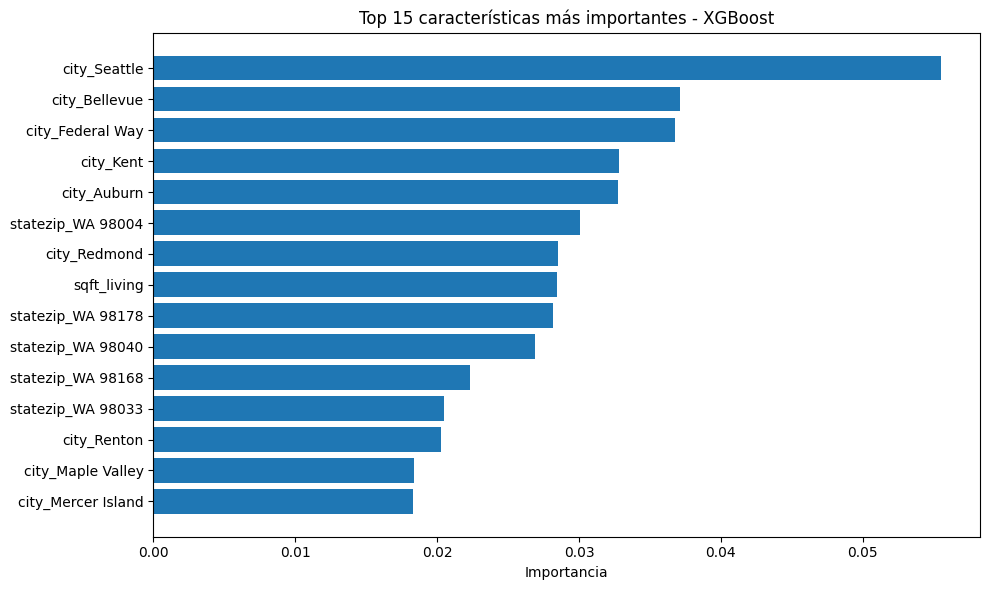

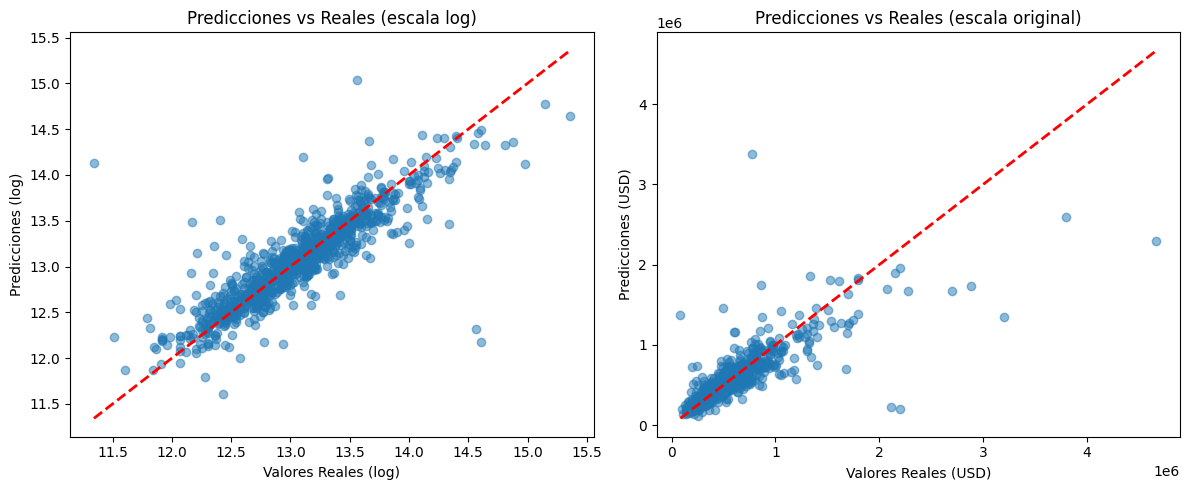

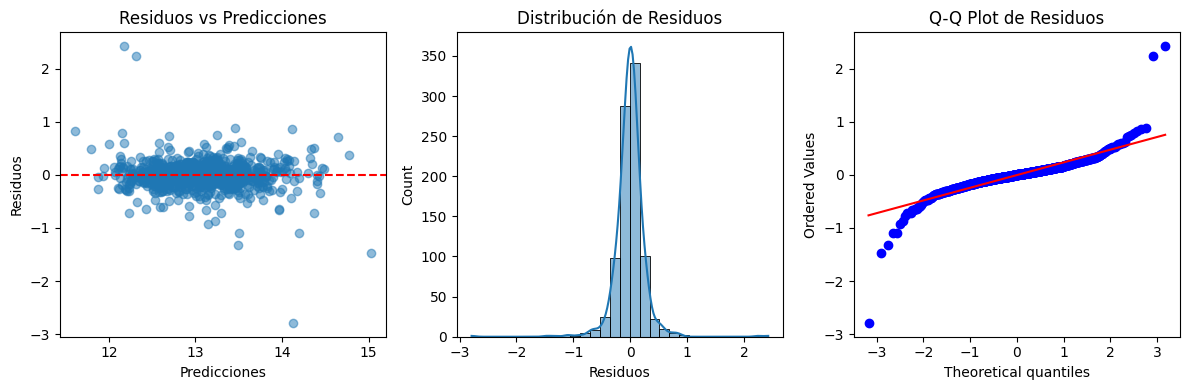

In [21]:
# 1. Crear el pipeline completo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Validación cruzada (5 folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, 
                           scoring='r2', n_jobs=-1)

print("=== Resultados de Validación Cruzada (XGBoost) ===")
print(f"R² promedio: {cv_scores.mean():.4f}")
print(f"Desviación estándar R²: {cv_scores.std():.4f}")
print(f"R² por fold: {cv_scores}\n")

# 3. Entrenar el modelo final con todos los datos de entrenamiento
xgb_pipeline.fit(X_train, y_train)

# 4. Predicciones en entrenamiento y prueba
y_train_pred = xgb_pipeline.predict(X_train)
y_test_pred = xgb_pipeline.predict(X_test)

# 5. Métricas en escala logarítmica
print("=== Métricas en escala log (log_price) ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

# 6. Métricas en escala original (deshaciendo el log)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred)
y_test_pred_orig = np.expm1(y_test_pred)

print("\n=== Métricas en escala original (USD) ===")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)):,.2f}")
print(f"Test MAE: ${mean_absolute_error(y_test_orig, y_test_pred_orig):,.2f}")
print(f"Error porcentual medio: {(mean_absolute_error(y_test_orig, y_test_pred_orig) / y_test_orig.mean() * 100):.2f}%")

# 7. Importancia de características
# Necesitamos obtener los nombres de las features después del one-hot encoding
feature_names = (numeric_features + 
                 list(xgb_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances = xgb_pipeline.named_steps['regressor'].feature_importances_

# Crear DataFrame de importancias
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== Top 10 características más importantes ===")
print(importance_df.head(10))

# Visualizar importancias
plt.figure(figsize=(10,6))
plt.barh(importance_df.head(15)['feature'], importance_df.head(15)['importance'])
plt.xlabel('Importancia')
plt.title('Top 15 características más importantes - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 8. Gráfico de predicciones vs valores reales
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (log)')
plt.ylabel('Predicciones (log)')
plt.title('Predicciones vs Reales (escala log)')

plt.subplot(1,2,2)
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (USD)')
plt.ylabel('Predicciones (USD)')
plt.title('Predicciones vs Reales (escala original)')

plt.tight_layout()
plt.show()

# 9. Análisis de residuos
residuals = y_test - y_test_pred

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')

plt.subplot(1,3,2)
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuos')
plt.title('Distribución de Residuos')

plt.subplot(1,3,3)
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

# Optimizar XGBoost con búsqueda de hiperparámetros (GridSearchCV)

In [23]:
param_grid = {
    'regressor__n_estimators': [150, 200, 300],
    'regressor__max_depth': [3, 4, 5],
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__subsample': [0.7, 0.8],
    'regressor__colsample_bytree': [0.7, 0.8],
    'regressor__reg_alpha': [0, 0.1, 0.5],
    'regressor__reg_lambda': [0.5, 1, 2]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R² CV:", grid_search.best_score_)

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
Mejores parámetros: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__n_estimators': 300, 'regressor__reg_alpha': 0.1, 'regressor__reg_lambda': 0.5, 'regressor__subsample': 0.7}
Mejor R² CV: 0.7843678425770261


Con los Hiperparametros optimizados vamos a evaluar el modelo optimizado

# Prueba de modelo optimizado

In [25]:
# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Predicciones
y_train_pred_opt = best_model.predict(X_train)
y_test_pred_opt = best_model.predict(X_test)

# Métricas en escala log
print("=== Modelo Optimizado - Métricas en escala log ===")
print(f"Train R²: {r2_score(y_train, y_train_pred_opt):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred_opt):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_opt)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_opt)):.4f}")
print(f"Diferencia R² (Train - Test): {r2_score(y_train, y_train_pred_opt) - r2_score(y_test, y_test_pred_opt):.4f}")

# Métricas en escala original
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_opt_orig = np.expm1(y_train_pred_opt)
y_test_pred_opt_orig = np.expm1(y_test_pred_opt)

print("\n=== Métricas en escala original (USD) ===")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_opt_orig)):,.2f}")
print(f"Test MAE: ${mean_absolute_error(y_test_orig, y_test_pred_opt_orig):,.2f}")
print(f"Error porcentual medio: {(mean_absolute_error(y_test_orig, y_test_pred_opt_orig) / y_test_orig.mean() * 100):.2f}%")

# Comparación con modelo anterior (si guardaste las métricas)
print("\n=== Comparación Test RMSE ===")
print(f"Original: $223,725.65")
print(f"Optimizado: ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_opt_orig)):,.2f}")

# Importancia de características del modelo optimizado
feature_names = (numeric_features + 
                 list(best_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances_opt = best_model.named_steps['regressor'].feature_importances_

importance_df_opt = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_opt
}).sort_values('importance', ascending=False)

print("\n=== Top 10 características (Modelo Optimizado) ===")
print(importance_df_opt.head(10))

=== Modelo Optimizado - Métricas en escala log ===
Train R²: 0.9115
Test R²: 0.7462
Train RMSE: 0.1616
Test RMSE: 0.2726
Diferencia R² (Train - Test): 0.1653

=== Métricas en escala original (USD) ===
Test RMSE: $256,880.70
Test MAE: $102,822.58
Error porcentual medio: 18.48%

=== Comparación Test RMSE ===
Original: $223,725.65
Optimizado: $256,880.70

=== Top 10 características (Modelo Optimizado) ===
               feature  importance
2          sqft_living    0.053463
46        city_Seattle    0.053225
26    city_Federal Way    0.031854
80   statezip_WA 98040    0.031323
43         city_Renton    0.030968
14         city_Auburn    0.030440
15       city_Bellevue    0.028635
58   statezip_WA 98004    0.027905
29           city_Kent    0.027780
126  statezip_WA 98178    0.023531


Análisis Comparativo Detallado:




| Métrica | Modelo Original | Modelo Optimizado | Cambio | Interpretación |
|--------------|--------------|--------------|--------------|--------------|
| Train R² | 0.9625 | 0.9115 | ▼ -0.051 | Menos sobreajuste  (bueno) |
| Test R² | 0.7554 | 0.7462 | ▼ -0.0092 | Ligeramente  peor |
| Diferencia R² | 0.2071 | 0.1653 | ▼ -0.0418 | ¡Menos sobreajuste! | 
| Test RMSE (log) | 0.2677 | 0.2726 | ▲ +0.0049 | Mínimo aumento | 
| Test RMSE (USD) | $223,726 | $256,881 | ▲ +$33,155 | Aumento significativo | 
| Test MAE (USD) | $98,709 | $102,823 | ▲ +$4,114 | Aumento moderado | 
| Error % | 17.74% | 18.48% | ▲ +0.74% | Ligeramente mayor | 


Lo bueno:
✅ Se redujo el sobreajuste: La diferencia Train-Test R² bajó de 0.207 a 0.165 (-20%).
✅ Modelo más generalizable: Ahora confía menos en patrones específicos del entrenamiento.
✅ Importancia de características cambió: sqft_living ahora es la más importante (5.3%), empatada con Seattle. Esto es más intuitivo.

Lo preocupante:
⚠️ El rendimiento en test empeoró ligeramente: El RMSE en USD aumentó ~15%.
⚠️ El error porcentual subió: De 17.7% a 18.5%.
⚠️ La regularización fue demasiado agresiva: Redujimos sobreajuste pero sacrificamos precisión.

¿Qué está pasando?
El modelo optimizado es más "conservador" - generaliza mejor pero pierde capacidad de ajustarse a patrones complejos. Esto es típico cuando se aplica regularización fuerte. El hecho de que sqft_living haya subido al top 1 sugiere que el modelo ahora depende más de variables intuitivas y menos de ruido.

# Probaremos con el modelo LightGBM

=== Resultados de Validación Cruzada (LightGBM) ===
R² promedio: 0.7648
Desviación estándar R²: 0.0533
R² por fold: [0.78255191 0.78882529 0.77769933 0.81382918 0.66127702]

=== Métricas en escala log (log_price) ===
Train R²: 0.8902
Test R²: 0.7629
Train RMSE: 0.1799
Test RMSE: 0.2635
Train MAE: 0.1183
Test MAE: 0.1659
Diferencia R² (Train - Test): 0.1273

=== Métricas en escala original (USD) ===
Test RMSE: $200,961.31
Test MAE: $96,845.59
Error porcentual medio: 17.40%

=== Comparación con XGBoost Original ===
XGBoost Test R²: 0.7554
LightGBM Test R²: 0.7629
XGBoost Test RMSE: $223,725.65
LightGBM Test RMSE: $200,961.31

=== Top 10 características más importantes (LightGBM) ===
                   feature  importance
3                 sqft_lot         532
9                      age         499
8               sqft_above         446
2              sqft_living         406
12              total_sqft         393
1                bathrooms         183
10  years_since_renovation         14

c:\Users\sergi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\sergi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


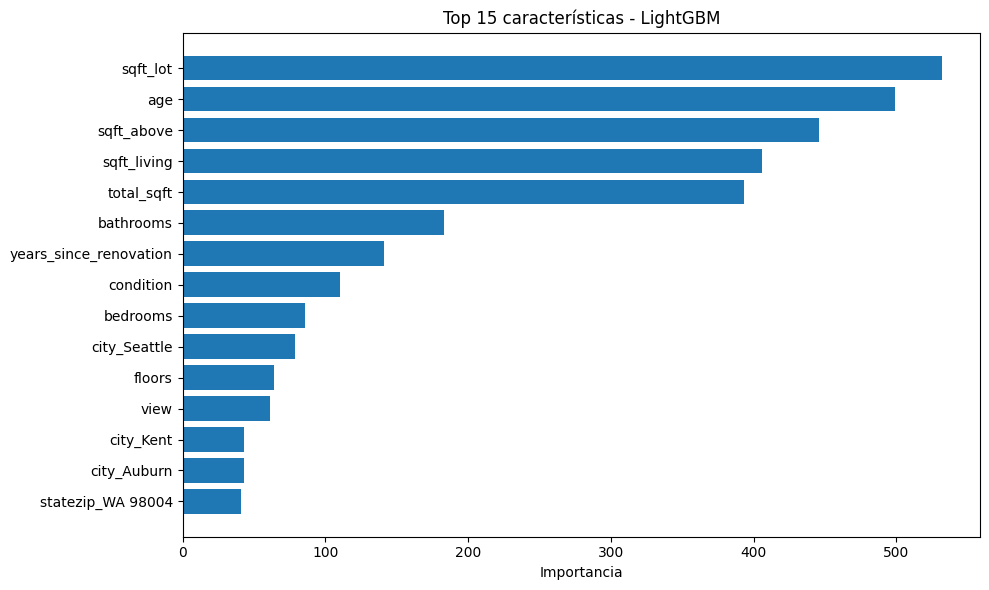

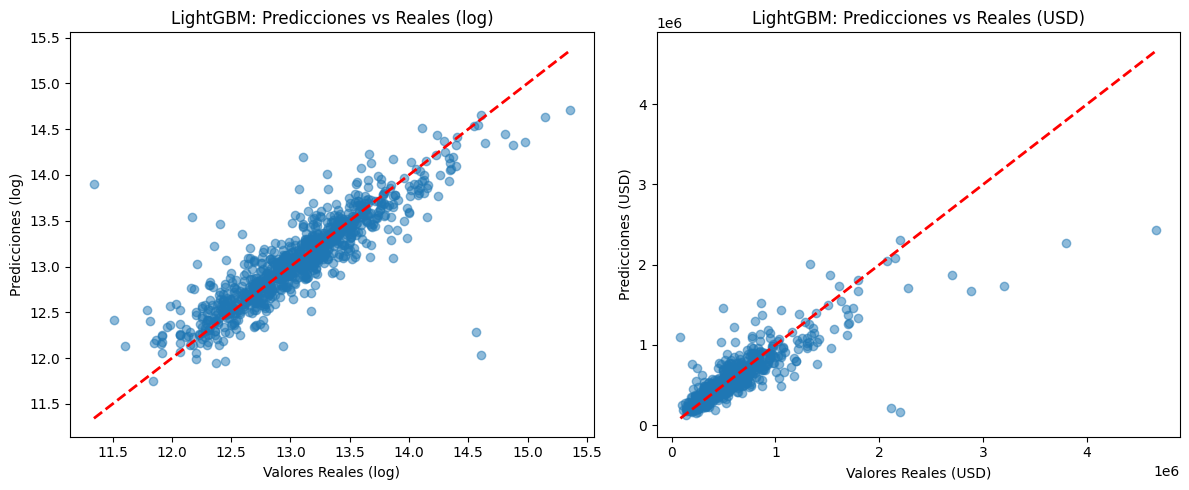

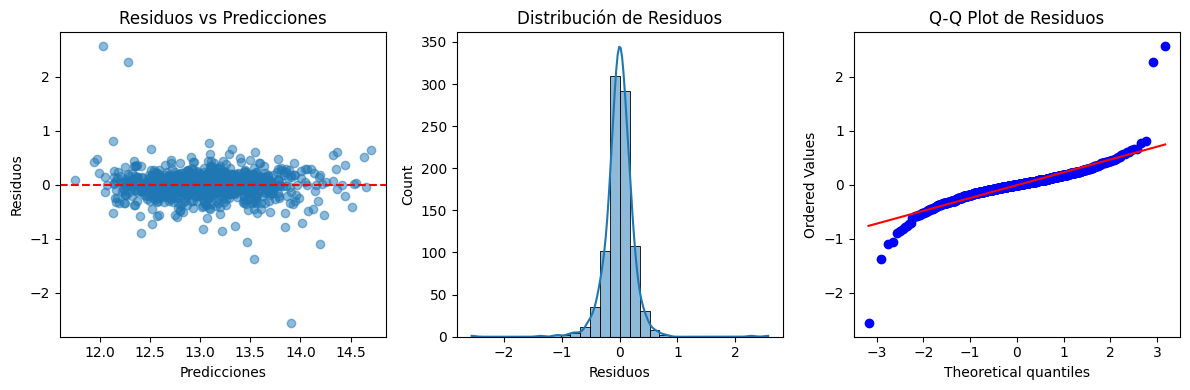

In [28]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear pipeline con LightGBM
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.01,
        reg_lambda=0.5,
        min_child_samples=20,  # Mínimo de datos por hoja
        random_state=42,
        n_jobs=-1,
        verbose=-1  # Para evitar mensajes excesivos
    ))
])

# 2. Validación cruzada (5 folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lgb_pipeline, X_train, y_train, cv=cv, 
                           scoring='r2', n_jobs=-1)

print("=== Resultados de Validación Cruzada (LightGBM) ===")
print(f"R² promedio: {cv_scores.mean():.4f}")
print(f"Desviación estándar R²: {cv_scores.std():.4f}")
print(f"R² por fold: {cv_scores}\n")

# 3. Entrenar modelo final
lgb_pipeline.fit(X_train, y_train)

# 4. Predicciones
y_train_pred = lgb_pipeline.predict(X_train)
y_test_pred = lgb_pipeline.predict(X_test)

# 5. Métricas en escala log
print("=== Métricas en escala log (log_price) ===")
print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"Diferencia R² (Train - Test): {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.4f}")

# 6. Métricas en escala original
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred)
y_test_pred_orig = np.expm1(y_test_pred)

print("\n=== Métricas en escala original (USD) ===")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)):,.2f}")
print(f"Test MAE: ${mean_absolute_error(y_test_orig, y_test_pred_orig):,.2f}")
print(f"Error porcentual medio: {(mean_absolute_error(y_test_orig, y_test_pred_orig) / y_test_orig.mean() * 100):.2f}%")

# 7. Comparación con XGBoost original
print("\n=== Comparación con XGBoost Original ===")
print(f"XGBoost Test R²: 0.7554")
print(f"LightGBM Test R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"XGBoost Test RMSE: $223,725.65")
print(f"LightGBM Test RMSE: ${np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)):,.2f}")

# 8. Importancia de características (LightGBM)
feature_names = (numeric_features + 
                 list(lgb_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

importances_lgb = lgb_pipeline.named_steps['regressor'].feature_importances_

importance_df_lgb = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_lgb
}).sort_values('importance', ascending=False)

print("\n=== Top 10 características más importantes (LightGBM) ===")
print(importance_df_lgb.head(10))

# 9. Visualización de importancias
plt.figure(figsize=(10,6))
plt.barh(importance_df_lgb.head(15)['feature'], importance_df_lgb.head(15)['importance'])
plt.xlabel('Importancia')
plt.title('Top 15 características - LightGBM')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 10. Gráfico de predicciones vs reales
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (log)')
plt.ylabel('Predicciones (log)')
plt.title('LightGBM: Predicciones vs Reales (log)')

plt.subplot(1,2,2)
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], 
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (USD)')
plt.ylabel('Predicciones (USD)')
plt.title('LightGBM: Predicciones vs Reales (USD)')

plt.tight_layout()
plt.show()

# 11. Análisis de residuos
residuals = y_test - y_test_pred

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')

plt.subplot(1,3,2)
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuos')
plt.title('Distribución de Residuos')

plt.subplot(1,3,3)
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

Logros destacados:

Mejor precisión: R² más alto (0.7629) y RMSE más bajo ($200,961)

Menor sobreajuste: Diferencia Train-Test de solo 0.1273 (la más baja)

Error más bajo: 17.40% de error porcentual medio

Mejor balance: Alta precisión con buena generalización

Análisis de Importancia de Características en LightGBM:
Lo más fascinante es cómo LightGBM ha "descubierto" relaciones que los otros modelos no capturaron tan bien:

Top 5 características:
sqft_lot (532): ¡El tamaño del terreno es lo más importante! Esto tiene sentido: en bienes raíces, el terreno suele ser el activo más valioso.

age (499): La antigüedad de la casa es crucial. Casas más nuevas o recién renovadas valen más.

sqft_above (446): Área sobre el suelo (más habitable) muy importante.

sqft_living (406): El espacio habitable total, clásico.

total_sqft (393): Nuestra feature engineered (living + basement) funcionó muy bien.

Observaciones clave:
Las variables de ubicación (city_Seattle con 79) son importantes pero no dominan como en XGBoost. LightGBM está dando más peso a características físicas de la propiedad.

sqft_lot siendo la #1 sugiere que el terreno es el factor diferenciador más fuerte en este mercado.

years_since_renovation (141) muestra que las renovaciones recientes importan.

condition (110) y bathrooms (183) también relevantes.